In [36]:
# Import packages
import scanpy as sc
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import gseapy as gp
import networkx as nx
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union
from scipy.stats import zscore

In [27]:
# Gene-Network Analysis
xls = pd.ExcelFile('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/GSEA/GSEA.leiden_0.25.significant.xlsx')
xls.sheet_names

['GSEA.leiden_res_.25_0',
 'GSEA.leiden_res_.25_1',
 'GSEA.leiden_res_.25_10',
 'GSEA.leiden_res_.25_11',
 'GSEA.leiden_res_.25_2',
 'GSEA.leiden_res_.25_3',
 'GSEA.leiden_res_.25_4',
 'GSEA.leiden_res_.25_5',
 'GSEA.leiden_res_.25_6',
 'GSEA.leiden_res_.25_7',
 'GSEA.leiden_res_.25_8',
 'GSEA.leiden_res_.25_9']

In [3]:
# GSEA Cluster 5 (Significant Pathways)
gsea_5 = pd.read_excel('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/GSEA/GSEA.leiden_0.25.significant.xlsx', sheet_name='GSEA.leiden_res_.25_5')

In [4]:
# Create a copy of the DataFrame and rename the necessary columns
gsea_5_copy = gsea_5.rename(columns={'pathway': 'Term', 'leadingEdge': 'Lead_genes'})

# Use the modified DataFrame in the enrichment_map() function
nodes, edges = gp.enrichment_map(gsea_5_copy, column='padj')

In [5]:
# Edges aren't defined properly
edge_list = []
num_nodes = len(nodes)
for i in range(num_nodes):
    # nodes.append([i, self.data.iloc[i, term_loc], self.data.iloc[i, ns_loc]])
    # if group_loc is not None:
    #     nodes[-1].append(self.data.iloc[i, group_loc])
    for j in range(i + 1, num_nodes):
        # Extract gene sets for pathway i and pathway j
        set_i = set(nodes['Lead_genes'].iloc[i].split(','))
        set_j = set(nodes['Lead_genes'].iloc[j].split(','))
        
        # See if any of these genes are overlapping
        ov = set_i.intersection(set_j)
        #print(ov)
        
        # Compute the overlap and Jaccard coefficient
        jaccard_coefficient = len(ov) / len(set_i.union(set_j))
        #print(jaccard_coefficient)
        
        overlap_coefficient = len(ov) / min(len(set_i), len(set_j))
        #print(overlap_coefficient)
        
        # Define the edges
        edge = [
            i,
            j,
            nodes.iloc[i]['Term'],  # Pathway name for pathway i
            nodes.iloc[j]['Term'],  # Pathway name for pathway j
            jaccard_coefficient,
            overlap_coefficient,
            ",".join(ov),
        ]
        
        #print(edge)
        
        edge_list.append(edge)
        #print(edge_list)
        
        edges = pd.DataFrame(
            edge_list,
            columns=[
                "src_idx",
                "targ_idx",
                "src_name",
                "targ_name",
                "jaccard_coef",
                "overlap_coef",
                "overlap_genes",
            ])

In [6]:
# Build graph
G = nx.from_pandas_edgelist(edges,
                            source='src_idx',
                            target='targ_idx',
                            edge_attr=['jaccard_coef', 'overlap_coef', 'overlap_genes'])

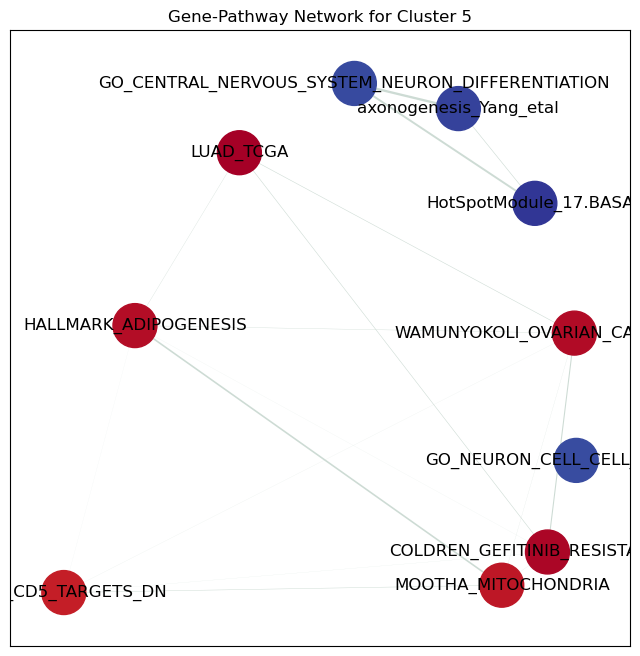

In [8]:
# Plot the gene-pathway network
fig, ax = plt.subplots(figsize=(8, 8))

# init node cooridnates
pos=nx.layout.spiral_layout(G)
#node_size = nx.get_node_attributes()
# draw node
nx.draw_networkx_nodes(G,
                       pos=pos,
                       cmap=plt.cm.RdYlBu,
                       node_color=list(nodes.NES),
                       node_size=list(nodes.Hits_ratio *1000))
# draw node label
nx.draw_networkx_labels(G,
                        pos=pos,
                        labels=nodes.Term.to_dict())
# draw edge
edge_weight = nx.get_edge_attributes(G, 'jaccard_coef').values()
nx.draw_networkx_edges(G,
                       pos=pos,
                       width=list(map(lambda x: x*10, edge_weight)),
                       edge_color='#CDDBD4')

plt.title('Gene-Pathway Network for Cluster 5')
plt.show()


In [4]:
# GSEA Cluster 10 (Significant Pathways)
gsea_10 = pd.read_excel('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/GSEA/GSEA.leiden_0.25.significant.xlsx', sheet_name='GSEA.leiden_res_.25_10')

In [5]:
# Create a copy of the DataFrame and rename the necessary columns
gsea_10_copy = gsea_10.rename(columns={'pathway': 'Term', 'leadingEdge': 'Lead_genes'})

# Use the modified DataFrame in the enrichment_map() function
nodes, edges = gp.enrichment_map(gsea_10_copy, column='padj')

In [6]:
# Edges aren't defined properly
edge_list = []
num_nodes = len(nodes)
for i in range(num_nodes):
    # nodes.append([i, self.data.iloc[i, term_loc], self.data.iloc[i, ns_loc]])
    # if group_loc is not None:
    #     nodes[-1].append(self.data.iloc[i, group_loc])
    for j in range(i + 1, num_nodes):
        # Extract gene sets for pathway i and pathway j
        set_i = set(nodes['Lead_genes'].iloc[i].split(','))
        set_j = set(nodes['Lead_genes'].iloc[j].split(','))
        
        # See if any of these genes are overlapping
        ov = set_i.intersection(set_j)
        #print(ov)
        
        # Compute the overlap and Jaccard coefficient
        jaccard_coefficient = len(ov) / len(set_i.union(set_j))
        #print(jaccard_coefficient)
        
        overlap_coefficient = len(ov) / min(len(set_i), len(set_j))
        #print(overlap_coefficient)
        
        # Define the edges
        edge = [
            i,
            j,
            nodes.iloc[i]['Term'],  # Pathway name for pathway i
            nodes.iloc[j]['Term'],  # Pathway name for pathway j
            jaccard_coefficient,
            overlap_coefficient,
            ",".join(ov),
        ]
        
        #print(edge)
        
        edge_list.append(edge)
        #print(edge_list)
        
        edges = pd.DataFrame(
            edge_list,
            columns=[
                "src_idx",
                "targ_idx",
                "src_name",
                "targ_name",
                "jaccard_coef",
                "overlap_coef",
                "overlap_genes",
            ])

In [7]:
nodes

,Term,pval,padj,log2err,ES,NES,size,Lead_genes,Hits_ratio
node_idx,,,,,,,,,
0,SOX9_TARGET_GENES _KADAJA,0.003346,0.036316,0.431708,0.911566,1.580394,12,"S100A4,WWP2",1.0
1,TONKS_TARGETS_OF_RUNX1_RUNX1T1_FUSION_MONOCYTE_UP,0.003546,0.037794,0.431708,0.567995,1.424892,170,"CKB,EIF5A,HSPB1,FGFR1,NR2F6,CDC123,NHP2,SASH1,...",1.0
2,ERB2_UP.V1_DN,0.003594,0.037794,0.431708,-0.503831,-1.422566,162,"SMARCA5,ASS1,MAD2L1,PLA2G12A,FHL2,RALGAPA1,SLC...",1.0
3,HALLMARK_MYOGENESIS,0.003887,0.040248,0.431708,0.594327,1.492639,161,"CKB,CDH13,DAPK2,MYL3,SYNGR2,EPHB3,MYL6B,NAV2,B...",1.0
4,KANG_DOXORUBICIN_RESISTANCE_UP,0.003949,0.040263,0.407018,-0.664909,-1.624961,50,"HMGB2,MAD2L1,TOP2A,CDK1,NQO1,AURKA,RRM1,NUSAP1...",1.0
5,INGRAM_SHH_TARGETS_DN,0.004092,0.041105,0.407018,0.749399,1.587431,43,"EREG,MRPL54,MME,CDC37,SND1,BAMBI,TGFBI,SDC1,CC...",1.0
6,GO_POSITIVE_REGULATION_OF_WNT_SIGNALING_PATHWAY,0.004463,0.043538,0.407018,0.597581,1.461672,134,"NFKB1,NKD1,LGR5,PSMD8,DAPK3,AXIN2,MLLT3,DISC1,...",1.0
7,axonogenesis_Yang_etal,0.004464,0.043538,0.407018,0.718958,1.568861,54,"SEMA3A,ALCAM,EPHB3,EPHB2,SEMA5A,TIAM1,LRP8,SEM...",1.0
8,GO_REGULATION_OF_NEURON_PROJECTION_DEVELOPMENT,0.004750,0.045028,0.407018,0.524084,1.388577,332,"SEMA3A,ID1,PTPRD,CAMK1D,NRCAM,FGFR1,EPHB3,EPHB...",1.0


In [9]:
# Build graph
G = nx.from_pandas_edgelist(edges,
                            source='src_idx',
                            target='targ_idx',
                            edge_attr=['jaccard_coef', 'overlap_coef', 'overlap_genes'])

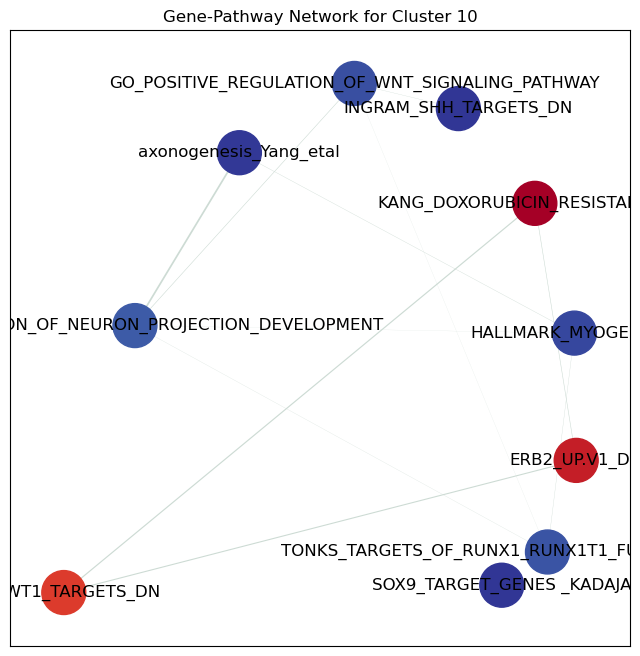

In [14]:
# Plot the gene-pathway network
fig, ax = plt.subplots(figsize=(8, 8))

# init node cooridnates
pos=nx.layout.spiral_layout(G)
#node_size = nx.get_node_attributes()
# draw node
nx.draw_networkx_nodes(G,
                       pos=pos,
                       cmap=plt.cm.RdYlBu,
                       node_color=list(nodes.NES),
                       node_size=list(nodes.Hits_ratio *1000))
# draw node label
nx.draw_networkx_labels(G,
                        pos=pos,
                        labels=nodes.Term.to_dict())
# draw edge
edge_weight = nx.get_edge_attributes(G, 'jaccard_coef').values()
nx.draw_networkx_edges(G,
                       pos=pos,
                       width=list(map(lambda x: x*10, edge_weight)),
                       edge_color='#CDDBD4')

plt.title('Gene-Pathway Network for Cluster 10')
plt.show()

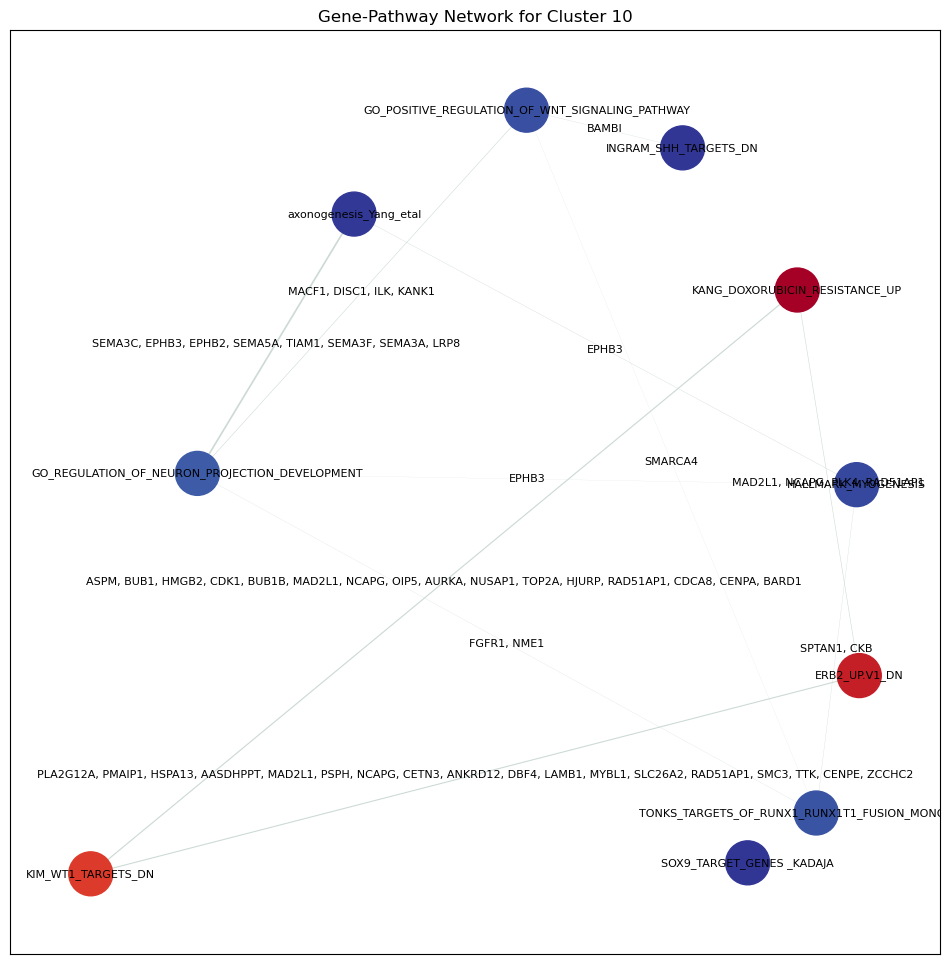

In [17]:
import matplotlib.pyplot as plt

# Plot the gene-pathway network
fig, ax = plt.subplots(figsize=(12, 12))

# Draw nodes
nx.draw_networkx_nodes(G,
                       pos=pos,
                       cmap=plt.cm.RdYlBu,
                       node_color=list(nodes.NES),
                       node_size=list(nodes.Hits_ratio * 1000))

# Draw node labels with pathway information
node_labels = {node: nodes['Term'].iloc[node] for node in G.nodes()}
nx.draw_networkx_labels(G,
                        pos=pos,
                        labels=node_labels,
                        font_size=8)  # Decreased font size here

# Draw edges
edge_weight = nx.get_edge_attributes(G, 'jaccard_coef').values()
nx.draw_networkx_edges(G,
                       pos=pos,
                       width=list(map(lambda x: x * 10, edge_weight)),
                       edge_color='#CDDBD4')

# Draw edge labels with overlapping genes information
for edge in edges.itertuples(index=False):
    src_node = edge[0]
    targ_node = edge[1]
    overlap_genes = edge[6].split(',')  # Get the overlapping genes
    edge_label = ', '.join(overlap_genes)
    midpoint = (pos[src_node][0] + pos[targ_node][0]) / 2, (pos[src_node][1] + pos[targ_node][1]) / 2
    plt.text(midpoint[0], midpoint[1], edge_label, fontsize=8, ha='center', va='center')

plt.title('Gene-Pathway Network for Cluster 10')
plt.show()


In [19]:
# GSEA Cluster 9 (Significant Pathways)
gsea_9 = pd.read_excel('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/GSEA/GSEA.leiden_0.25.significant.xlsx', sheet_name='GSEA.leiden_res_.25_9')

In [20]:
# Create a copy of the DataFrame and rename the necessary columns
gsea_9_copy = gsea_9.rename(columns={'pathway': 'Term', 'leadingEdge': 'Lead_genes'})

# Use the modified DataFrame in the enrichment_map() function
nodes, edges = gp.enrichment_map(gsea_9_copy, column='padj')

In [21]:
# Edges aren't defined properly
edge_list = []
num_nodes = len(nodes)
for i in range(num_nodes):
    # nodes.append([i, self.data.iloc[i, term_loc], self.data.iloc[i, ns_loc]])
    # if group_loc is not None:
    #     nodes[-1].append(self.data.iloc[i, group_loc])
    for j in range(i + 1, num_nodes):
        # Extract gene sets for pathway i and pathway j
        set_i = set(nodes['Lead_genes'].iloc[i].split(','))
        set_j = set(nodes['Lead_genes'].iloc[j].split(','))
        
        # See if any of these genes are overlapping
        ov = set_i.intersection(set_j)
        #print(ov)
        
        # Compute the overlap and Jaccard coefficient
        jaccard_coefficient = len(ov) / len(set_i.union(set_j))
        #print(jaccard_coefficient)
        
        overlap_coefficient = len(ov) / min(len(set_i), len(set_j))
        #print(overlap_coefficient)
        
        # Define the edges
        edge = [
            i,
            j,
            nodes.iloc[i]['Term'],  # Pathway name for pathway i
            nodes.iloc[j]['Term'],  # Pathway name for pathway j
            jaccard_coefficient,
            overlap_coefficient,
            ",".join(ov),
        ]
        
        #print(edge)
        
        edge_list.append(edge)
        #print(edge_list)
        
        edges = pd.DataFrame(
            edge_list,
            columns=[
                "src_idx",
                "targ_idx",
                "src_name",
                "targ_name",
                "jaccard_coef",
                "overlap_coef",
                "overlap_genes",
            ])

In [22]:
# Build graph
G = nx.from_pandas_edgelist(edges,
                            source='src_idx',
                            target='targ_idx',
                            edge_attr=['jaccard_coef', 'overlap_coef', 'overlap_genes'])

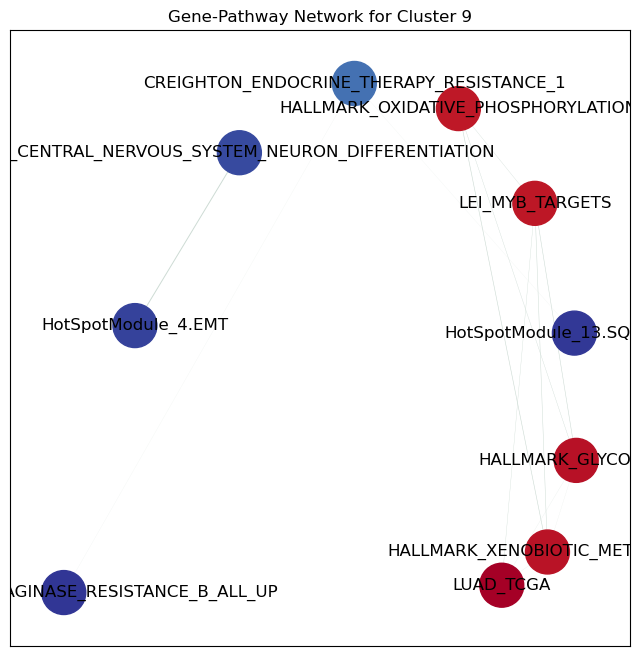

In [23]:
# Plot the gene-pathway network
fig, ax = plt.subplots(figsize=(8, 8))

# init node cooridnates
pos=nx.layout.spiral_layout(G)
#node_size = nx.get_node_attributes()
# draw node
nx.draw_networkx_nodes(G,
                       pos=pos,
                       cmap=plt.cm.RdYlBu,
                       node_color=list(nodes.NES),
                       node_size=list(nodes.Hits_ratio *1000))
# draw node label
nx.draw_networkx_labels(G,
                        pos=pos,
                        labels=nodes.Term.to_dict())
# draw edge
edge_weight = nx.get_edge_attributes(G, 'jaccard_coef').values()
nx.draw_networkx_edges(G,
                       pos=pos,
                       width=list(map(lambda x: x*10, edge_weight)),
                       edge_color='#CDDBD4')

plt.title('Gene-Pathway Network for Cluster 9')
plt.show()

In [18]:
# CORRELATION OF NFKB1 GENE TO OTHER GENES IN AP1 PATHWAY

In [70]:
# Read in adata
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/adata.combined.postprocess.leiden.h5ad')

In [40]:
# Identify genes of interest
genes_of_interest = ['JUN', 'JUNB', 'FOS', 'ZFP36', 'ERBB2', 'ERBB3', 'FOSB',
                     'LIF', 'TFAP2C', 'CDX2', 'CDKN2A', 'WNT2B']
nfkb1_gene = ['NFKB1', 'NFKBIA']

In [109]:
# Convert adata to dataframe
expr_df = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names).apply(zscore)

In [111]:
expr_df

gene_name,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A3GALT2,A4GALT,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
KG146Li_BASE_shCtrl_TGCGGGTTCTCACCCA-1,-0.030117,-0.017386,-0.769378,-0.029743,-0.032675,-0.02562,-0.040014,-0.004352,-0.031606,-0.042426,...,-0.370981,-0.425244,-0.731689,-0.08676,-0.21222,-0.648087,-0.056566,-0.657073,-0.341287,-0.430176
KG146Li_HISC_shCtrl_ACTATCTGTAACGGTG-1,-0.030117,-0.017386,-0.769378,-0.029743,-0.032675,-0.02562,-0.040014,-0.004352,-0.031606,-0.042426,...,-0.370981,-0.425244,-0.731689,-0.08676,-0.21222,-0.648087,-0.056566,-0.657073,-0.341287,-0.430176
146P_HISC_shZFP36L2_3_TTGTGTTTCCCAAGTA-1,-0.030117,-0.017386,-0.769378,-0.029743,-0.032675,-0.02562,-0.040014,-0.004352,-0.031606,-0.042426,...,-0.370981,-0.425244,-0.731689,-0.08676,-0.21222,1.178770,-0.056566,1.182956,-0.341287,-0.430176
146Li_dedifferentiation_shCtrl_ATCGATGCACGGAAGT-1,-0.030117,-0.017386,0.799244,-0.029743,-0.032675,-0.02562,-0.040014,-0.004352,-0.031606,-0.042426,...,-0.370981,-0.425244,-0.731689,-0.08676,-0.21222,-0.648087,-0.056566,1.271896,-0.341287,-0.430176
146P_HISC_shCTRL_GTCGCGACAAGGCTTT-1,-0.030117,-0.017386,1.187598,-0.029743,-0.032675,-0.02562,-0.040014,-0.004352,-0.031606,-0.042426,...,-0.370981,-0.425244,-0.731689,-0.08676,-0.21222,-0.648087,-0.056566,1.749464,-0.341287,-0.430176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146P_dedifferentiation_shCtrl_CTCCGATTCATTCATC-1,-0.030117,-0.017386,-0.769378,-0.029743,-0.032675,-0.02562,-0.040014,-0.004352,-0.031606,-0.042426,...,-0.370981,-0.425244,-0.731689,-0.08676,-0.21222,-0.648087,-0.056566,-0.657073,-0.341287,-0.430176
KG146Li_BASE_shZFP36L2_4_CTGCTCAAGTAGCAAT-1,-0.030117,-0.017386,-0.769378,-0.029743,-0.032675,-0.02562,-0.040014,-0.004352,-0.031606,-0.042426,...,1.466301,-0.425244,-0.731689,-0.08676,-0.21222,0.435421,-0.056566,0.434247,-0.341287,0.951299
KG146Li_HISC_shZFP36L2_4_ATCCCTGCACGCTTAA-1,-0.030117,-0.017386,-0.769378,-0.029743,-0.032675,-0.02562,-0.040014,-0.004352,-0.031606,-0.042426,...,-0.370981,-0.425244,0.885604,-0.08676,-0.21222,-0.648087,-0.056566,-0.657073,-0.341287,2.031245
146Li_dedifferentiation_shCtrl_TACTTGTGTCTTACAG-1,-0.030117,-0.017386,0.089069,-0.029743,-0.032675,-0.02562,-0.040014,-0.004352,-0.031606,-0.042426,...,-0.370981,-0.425244,0.146351,-0.08676,-0.21222,2.484179,-0.056566,1.123429,-0.341287,-0.430176


In [112]:
# Compute the correlation
corrMatrix = expr_df[['NFKB1', 'JUN', 'JUNB', 'FOS', 'ZFP36', 'ERBB2', 'ERBB3', 'FOSB',
                     'LIF', 'TFAP2C', 'CDX2', 'CDKN2A', 'WNT2B']].corr()

In [113]:
corrMatrix

gene_name,NFKB1,JUN,JUNB,FOS,ZFP36,ERBB2,ERBB3,FOSB,LIF,TFAP2C,CDX2,CDKN2A,WNT2B
gene_name,,,,,,,,,,,,,
NFKB1,1.000000,0.050988,0.047299,0.014153,0.016398,-0.002892,-0.020964,0.103613,-0.011213,-0.005756,-0.045117,-0.030284,0.002077
JUN,0.050988,1.000000,0.305933,0.401251,0.227250,-0.007781,0.046220,0.221999,0.001934,0.006479,0.150481,-0.004620,0.020507
JUNB,0.047299,0.305933,1.000000,0.412965,0.260434,0.023557,0.063779,0.214089,0.012285,0.020281,0.158339,0.001328,0.005912
FOS,0.014153,0.401251,0.412965,1.000000,0.298755,0.034705,0.081021,0.301676,0.015940,0.021424,0.213232,-0.009476,0.029807
ZFP36,0.016398,0.227250,0.260434,0.298755,1.000000,0.029587,0.057349,0.143360,0.015705,0.006827,0.120490,0.003018,0.005041
ERBB2,-0.002892,-0.007781,0.023557,0.034705,0.029587,1.000000,0.052352,0.002850,0.008670,0.016109,0.039363,-0.005034,0.032720
ERBB3,-0.020964,0.046220,0.063779,0.081021,0.057349,0.052352,1.000000,0.026739,0.005593,0.008216,0.073684,-0.014810,0.043340
FOSB,0.103613,0.221999,0.214089,0.301676,0.143360,0.002850,0.026739,1.000000,0.013984,-0.000802,0.027902,-0.021456,0.022787
LIF,-0.011213,0.001934,0.012285,0.015940,0.015705,0.008670,0.005593,0.013984,1.000000,-0.003896,0.017605,-0.003779,0.004499


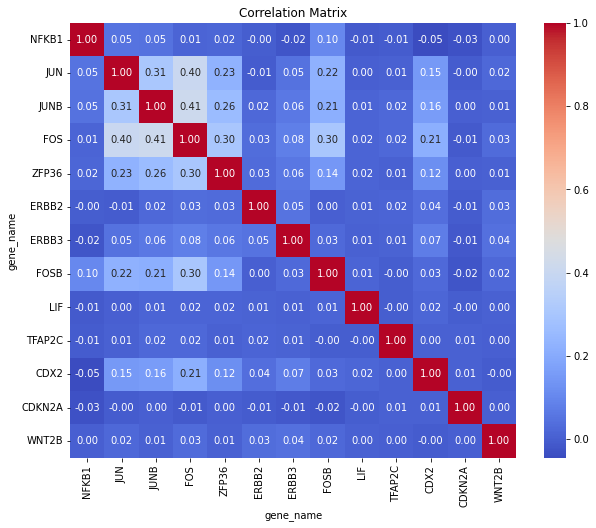

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

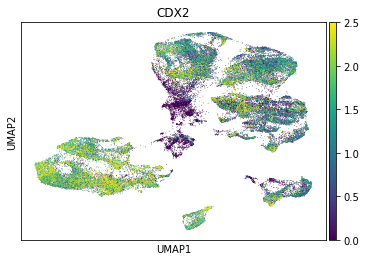

In [120]:
sc.pl.umap(adata, 
           color=['CDX2'],
           vmax=2.5
          )

In [85]:
corrMatrix

JUN     NaN
NFKB1   NaN
dtype: float64

In [41]:
# Select expression values for genes of interest and NF-kB1 gene
genes_expr = adata[:, genes_of_interest]
nfkb1_expr = adata[:, nfkb1_gene]

In [42]:
genes_expr

View of AnnData object with n_obs × n_vars = 52800 × 12
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden', 'leiden_res_.25', 'leiden_res_.5', 'leiden_res_1', 'leiden_res_0.1'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_

In [43]:
# Convert gene expression data to pandas DataFrame
genes_expr_df = pd.DataFrame(genes_expr.X.toarray(), index=genes_expr.obs_names, columns=genes_of_interest)
nfkb1_expr_df = pd.DataFrame(nfkb1_expr.X.toarray(), index=nfkb1_expr.obs_names, columns=[nfkb1_gene])

# Z-score normalization for gene expression data
genes_expr_zscore = genes_expr_df.apply(zscore)
nfkb1_expr_zscore = nfkb1_expr_df.apply(zscore)

In [44]:
nfkb1_expr_df

,NFKB1,NFKBIA
KG146Li_BASE_shCtrl_TGCGGGTTCTCACCCA-1,2.232003,0.000000
KG146Li_HISC_shCtrl_ACTATCTGTAACGGTG-1,0.000000,0.000000
146P_HISC_shZFP36L2_3_TTGTGTTTCCCAAGTA-1,0.000000,0.000000
146Li_dedifferentiation_shCtrl_ATCGATGCACGGAAGT-1,1.189179,1.832063
146P_HISC_shCTRL_GTCGCGACAAGGCTTT-1,1.483592,1.483592
...,...,...
146P_dedifferentiation_shCtrl_CTCCGATTCATTCATC-1,1.634790,0.000000
KG146Li_BASE_shZFP36L2_4_CTGCTCAAGTAGCAAT-1,0.000000,1.129802
KG146Li_HISC_shZFP36L2_4_ATCCCTGCACGCTTAA-1,1.844268,1.844268
146Li_dedifferentiation_shCtrl_TACTTGTGTCTTACAG-1,0.650792,0.000000


In [45]:
genes_expr_df

,JUN,JUNB,FOS,ZFP36,ERBB2,ERBB3,FOSB,LIF,TFAP2C,CDX2,CDKN2A,WNT2B
KG146Li_BASE_shCtrl_TGCGGGTTCTCACCCA-1,3.069653,3.069653,3.596169,2.232003,0.000000,0.000000,4.934651,0.0,0.0,0.000000,2.232003,0.000000
KG146Li_HISC_shCtrl_ACTATCTGTAACGGTG-1,1.991046,0.000000,0.000000,0.000000,0.000000,1.991046,0.000000,0.0,0.0,0.000000,0.000000,0.000000
146P_HISC_shZFP36L2_3_TTGTGTTTCCCAAGTA-1,3.695096,0.000000,2.197105,0.000000,1.134348,0.000000,0.000000,0.0,0.0,1.761450,0.000000,1.134348
146Li_dedifferentiation_shCtrl_ATCGATGCACGGAAGT-1,1.189179,0.000000,0.000000,0.000000,1.189179,0.000000,0.000000,0.0,0.0,1.189179,1.189179,0.000000
146P_HISC_shCTRL_GTCGCGACAAGGCTTT-1,2.199399,0.000000,0.000000,0.000000,1.483592,1.483592,0.000000,0.0,0.0,1.483592,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
146P_dedifferentiation_shCtrl_CTCCGATTCATTCATC-1,0.000000,1.634790,1.634790,1.634790,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
KG146Li_BASE_shZFP36L2_4_CTGCTCAAGTAGCAAT-1,1.129802,0.000000,1.476345,0.000000,0.000000,0.000000,1.129802,0.0,0.0,1.129802,0.000000,0.000000
KG146Li_HISC_shZFP36L2_4_ATCCCTGCACGCTTAA-1,1.198717,2.288672,1.198717,0.000000,1.198717,1.198717,1.198717,0.0,0.0,0.000000,0.000000,0.000000
146Li_dedifferentiation_shCtrl_TACTTGTGTCTTACAG-1,0.650792,0.000000,0.000000,0.000000,0.000000,1.438341,0.650792,0.0,0.0,0.650792,0.000000,0.000000


In [68]:
# Ensure numeric data and remove NaN values
genes_expr_df = genes_expr_df.dropna()
nfkb1_expr_df = nfkb1_expr_df.dropna()

# Z-score normalization for gene expression data
genes_expr_zscore = genes_expr_df.apply(zscore)
nfkb1_expr_zscore = nfkb1_expr_df.apply(zscore)

# Compute correlation
correlation_results = nfkb1_expr_zscore.transpose().corrwith(genes_expr_zscore, axis=1)

/scratch/lsftmp/5517326.tmpdir/ipykernel_97492/3619973721.py:10: RuntimeWarning: The values in the array are unorderable. Pass `sort=False` to suppress this warning.
  correlation_results = nfkb1_expr_zscore.transpose().corrwith(genes_expr_zscore, axis=1)


In [69]:
correlation_results

(NFKB1,)                                                 NaN
(NFKBIA,)                                                NaN
KG146Li_BASE_shCtrl_TGCGGGTTCTCACCCA-1                   NaN
KG146Li_HISC_shCtrl_ACTATCTGTAACGGTG-1                   NaN
146P_HISC_shZFP36L2_3_TTGTGTTTCCCAAGTA-1                 NaN
                                                          ..
146P_dedifferentiation_shCtrl_CTCCGATTCATTCATC-1         NaN
KG146Li_BASE_shZFP36L2_4_CTGCTCAAGTAGCAAT-1              NaN
KG146Li_HISC_shZFP36L2_4_ATCCCTGCACGCTTAA-1              NaN
146Li_dedifferentiation_shCtrl_TACTTGTGTCTTACAG-1        NaN
146Li_dedifferentiation_shZFP36L2_4_AACAACCAGGGAGAAT-1   NaN
Length: 52802, dtype: float64

In [66]:
# Compute correlation
correlation_results = nfkb1_expr_df.corrwith(genes_expr_df, axis=0, method=callable)

/scratch/lsftmp/5517326.tmpdir/ipykernel_97492/525960506.py:2: RuntimeWarning: The values in the array are unorderable. Pass `sort=False` to suppress this warning.
  correlation_results = nfkb1_expr_df.corrwith(genes_expr_df, axis=0, method=callable)
/scratch/lsftmp/5517326.tmpdir/ipykernel_97492/525960506.py:2: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  correlation_results = nfkb1_expr_df.corrwith(genes_expr_df, axis=0, method=callable)


In [67]:
correlation_results

(NFKB1,)    NaN
(NFKBIA,)   NaN
JUN         NaN
JUNB        NaN
FOS         NaN
ZFP36       NaN
ERBB2       NaN
ERBB3       NaN
FOSB        NaN
LIF         NaN
TFAP2C      NaN
CDX2        NaN
CDKN2A      NaN
WNT2B       NaN
dtype: float64

In [51]:
# Compute correlation
# Transpose genes expression DataFrame
genes_expr_df_transposed = genes_expr_zscore.transpose()

# Compute correlation
correlation_results = nfkb1_expr_df.corrwith(genes_expr_df_transposed, axis=1)

In [50]:
correlation_results

KG146Li_BASE_shCtrl_TGCGGGTTCTCACCCA-1                   NaN
KG146Li_HISC_shCtrl_ACTATCTGTAACGGTG-1                   NaN
146P_HISC_shZFP36L2_3_TTGTGTTTCCCAAGTA-1                 NaN
146Li_dedifferentiation_shCtrl_ATCGATGCACGGAAGT-1        NaN
146P_HISC_shCTRL_GTCGCGACAAGGCTTT-1                      NaN
                                                          ..
146P_dedifferentiation_shCtrl_CTCCGATTCATTCATC-1         NaN
KG146Li_BASE_shZFP36L2_4_CTGCTCAAGTAGCAAT-1              NaN
KG146Li_HISC_shZFP36L2_4_ATCCCTGCACGCTTAA-1              NaN
146Li_dedifferentiation_shCtrl_TACTTGTGTCTTACAG-1        NaN
146Li_dedifferentiation_shZFP36L2_4_AACAACCAGGGAGAAT-1   NaN
Length: 52800, dtype: float64

In [ ]:
import pandas as pd
import anndata

# Assuming your AnnData object is named 'adata'

# Convert AnnData object to pandas DataFrame
adata_df = pd.DataFrame(adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)

# Select columns for NF-kB1 gene and genes of interest (JUN/FOS genes and other AP-1 pathway members)
nfkb1_gene = adata_df['NF-kB1']  # Replace 'NF-kB1' with the actual gene name
ap1_genes = adata_df[['JUN', 'FOS', 'other_AP1_member1', 'other_AP1_member2', ...]]  # Replace with actual gene names

# Compute pairwise correlation between NF-kB1 gene and other genes
correlation_results = nfkb1_gene.corrwith(ap1_genes)

# Print correlation results
print(correlation_results)


In [113]:
nodes, edges = enrichment_map(gsea_5_copy, column='padj')

In [119]:
nodes

,Term,pval,padj,log2err,ES,NES,size,Lead_genes,Hits_ratio
node_idx,,,,,,,,,
0,SOX9_TARGET_GENES _KADAJA,0.003346,0.036316,0.431708,0.911566,1.580394,12,"S100A4,WWP2",1.0
1,TONKS_TARGETS_OF_RUNX1_RUNX1T1_FUSION_MONOCYTE_UP,0.003546,0.037794,0.431708,0.567995,1.424892,170,"CKB,EIF5A,HSPB1,FGFR1,NR2F6,CDC123,NHP2,SASH1,...",1.0
2,ERB2_UP.V1_DN,0.003594,0.037794,0.431708,-0.503831,-1.422566,162,"SMARCA5,ASS1,MAD2L1,PLA2G12A,FHL2,RALGAPA1,SLC...",1.0
3,HALLMARK_MYOGENESIS,0.003887,0.040248,0.431708,0.594327,1.492639,161,"CKB,CDH13,DAPK2,MYL3,SYNGR2,EPHB3,MYL6B,NAV2,B...",1.0
4,KANG_DOXORUBICIN_RESISTANCE_UP,0.003949,0.040263,0.407018,-0.664909,-1.624961,50,"HMGB2,MAD2L1,TOP2A,CDK1,NQO1,AURKA,RRM1,NUSAP1...",1.0
5,INGRAM_SHH_TARGETS_DN,0.004092,0.041105,0.407018,0.749399,1.587431,43,"EREG,MRPL54,MME,CDC37,SND1,BAMBI,TGFBI,SDC1,CC...",1.0
6,GO_POSITIVE_REGULATION_OF_WNT_SIGNALING_PATHWAY,0.004463,0.043538,0.407018,0.597581,1.461672,134,"NFKB1,NKD1,LGR5,PSMD8,DAPK3,AXIN2,MLLT3,DISC1,...",1.0
7,axonogenesis_Yang_etal,0.004464,0.043538,0.407018,0.718958,1.568861,54,"SEMA3A,ALCAM,EPHB3,EPHB2,SEMA5A,TIAM1,LRP8,SEM...",1.0
8,GO_REGULATION_OF_NEURON_PROJECTION_DEVELOPMENT,0.004750,0.045028,0.407018,0.524084,1.388577,332,"SEMA3A,ID1,PTPRD,CAMK1D,NRCAM,FGFR1,EPHB3,EPHB...",1.0


In [120]:
len(nodes)

10

In [2]:
edge_list = []
num_nodes = len(nodes)
for i in range(num_nodes):
    # nodes.append([i, self.data.iloc[i, term_loc], self.data.iloc[i, ns_loc]])
    # if group_loc is not None:
    #     nodes[-1].append(self.data.iloc[i, group_loc])
    for j in range(i + 1, num_nodes):
        # Extract gene sets for pathway i and pathway j
        set_i = set(nodes['Lead_genes'].iloc[i].split(','))
        set_j = set(nodes['Lead_genes'].iloc[j].split(','))
        
        # See if any of these genes are overlapping
        ov = set_i.intersection(set_j)
        #print(ov)
        
        # Compute the overlap and Jaccard coefficient
        jaccard_coefficient = len(ov) / len(set_i.union(set_j))
        #print(jaccard_coefficient)
        
        overlap_coefficient = len(ov) / min(len(set_i), len(set_j))
        #print(overlap_coefficient)
        
        # Define the edges
        edge = [
            i,
            j,
            nodes.iloc[i]['Term'],  # Pathway name for pathway i
            nodes.iloc[j]['Term'],  # Pathway name for pathway j
            jaccard_coefficient,
            overlap_coefficient,
            ",".join(ov),
        ]
        
        #print(edge)
        
        edge_list.append(edge)
        #print(edge_list)
        
        edges = pd.DataFrame(
            edge_list,
            columns=[
                "src_idx",
                "targ_idx",
                "src_name",
                "targ_name",
                "jaccard_coef",
                "overlap_coef",
                "overlap_genes",
            ])

NameError: name 'nodes' is not defined

In [140]:
edges

,src_idx,targ_idx,src_name,targ_name,jaccard_coef,overlap_coef,overlap_genes
0,0,1,SOX9_TARGET_GENES _KADAJA,TONKS_TARGETS_OF_RUNX1_RUNX1T1_FUSION_MONOCYTE_UP,0.000000,0.000000,
1,0,2,SOX9_TARGET_GENES _KADAJA,ERB2_UP.V1_DN,0.000000,0.000000,
2,0,3,SOX9_TARGET_GENES _KADAJA,HALLMARK_MYOGENESIS,0.000000,0.000000,
3,0,4,SOX9_TARGET_GENES _KADAJA,KANG_DOXORUBICIN_RESISTANCE_UP,0.000000,0.000000,
4,0,5,SOX9_TARGET_GENES _KADAJA,INGRAM_SHH_TARGETS_DN,0.000000,0.000000,
5,0,6,SOX9_TARGET_GENES _KADAJA,GO_POSITIVE_REGULATION_OF_WNT_SIGNALING_PATHWAY,0.000000,0.000000,
6,0,7,SOX9_TARGET_GENES _KADAJA,axonogenesis_Yang_etal,0.000000,0.000000,
7,0,8,SOX9_TARGET_GENES _KADAJA,GO_REGULATION_OF_NEURON_PROJECTION_DEVELOPMENT,0.000000,0.000000,
8,0,9,SOX9_TARGET_GENES _KADAJA,KIM_WT1_TARGETS_DN,0.000000,0.000000,
9,1,2,TONKS_TARGETS_OF_RUNX1_RUNX1T1_FUSION_MONOCYTE_UP,ERB2_UP.V1_DN,0.000000,0.000000,


In [141]:
# Build graph
G = nx.from_pandas_edgelist(edges,
                            source='src_idx',
                            target='targ_idx',
                            edge_attr=['jaccard_coef', 'overlap_coef', 'overlap_genes'])

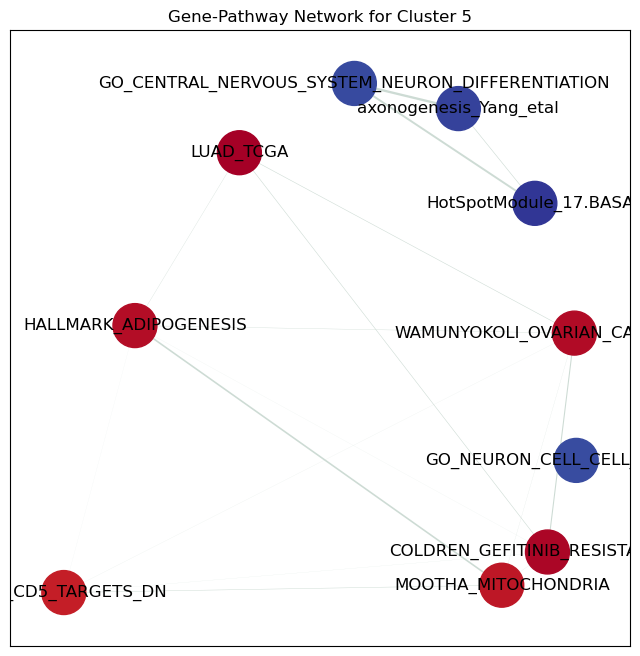

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

# init node cooridnates
pos=nx.layout.spiral_layout(G)
#node_size = nx.get_node_attributes()
# draw node
nx.draw_networkx_nodes(G,
                       pos=pos,
                       cmap=plt.cm.RdYlBu,
                       node_color=list(nodes.NES),
                       node_size=list(nodes.Hits_ratio *1000))
# draw node label
nx.draw_networkx_labels(G,
                        pos=pos,
                        labels=nodes.Term.to_dict())
# draw edge
edge_weight = nx.get_edge_attributes(G, 'jaccard_coef').values()
nx.draw_networkx_edges(G,
                       pos=pos,
                       width=list(map(lambda x: x*10, edge_weight)),
                       edge_color='#CDDBD4')

plt.title('Gene-Pathway Network for Cluster 5')
plt.show()


In [118]:
edge_list = []
num_nodes = len(nodes)
for i in range(num_nodes):
    # nodes.append([i, self.data.iloc[i, term_loc], self.data.iloc[i, ns_loc]])
    # if group_loc is not None:
    #     nodes[-1].append(self.data.iloc[i, group_loc])
    for j in range(i + 1, num_nodes):
        set_i = set(genes.iloc[i])
        set_j = set(genes.iloc[j])
        ov = set_i.intersection(set_j)
        if len(ov) < 1:
            continue
        jaccard_coefficient = len(ov) / len(set_i.union(set_j))
        print(jaccard_coefficient)
        overlap_coefficient = len(ov) / min(len(set_i), len(set_j))
        print(overlap_coefficient)
        edge = [
            i,
            j,
            self.data.iloc[i, term_loc],
            self.data.iloc[j, term_loc],
            jaccard_coefficient,
            overlap_coefficient,
            ",".join(ov),
        ]
        edge_list.append(edge)

NameError: name 'genes' is not defined

In [110]:
nodes

,Term,pval,padj,log2err,ES,NES,size,Lead_genes,Hits_ratio
node_idx,,,,,,,,,
0,SOX9_TARGET_GENES _KADAJA,0.003346,0.036316,0.431708,0.911566,1.580394,12,"S100A4,WWP2",1.0
1,TONKS_TARGETS_OF_RUNX1_RUNX1T1_FUSION_MONOCYTE_UP,0.003546,0.037794,0.431708,0.567995,1.424892,170,"CKB,EIF5A,HSPB1,FGFR1,NR2F6,CDC123,NHP2,SASH1,...",1.0
2,ERB2_UP.V1_DN,0.003594,0.037794,0.431708,-0.503831,-1.422566,162,"SMARCA5,ASS1,MAD2L1,PLA2G12A,FHL2,RALGAPA1,SLC...",1.0
3,HALLMARK_MYOGENESIS,0.003887,0.040248,0.431708,0.594327,1.492639,161,"CKB,CDH13,DAPK2,MYL3,SYNGR2,EPHB3,MYL6B,NAV2,B...",1.0
4,KANG_DOXORUBICIN_RESISTANCE_UP,0.003949,0.040263,0.407018,-0.664909,-1.624961,50,"HMGB2,MAD2L1,TOP2A,CDK1,NQO1,AURKA,RRM1,NUSAP1...",1.0
5,INGRAM_SHH_TARGETS_DN,0.004092,0.041105,0.407018,0.749399,1.587431,43,"EREG,MRPL54,MME,CDC37,SND1,BAMBI,TGFBI,SDC1,CC...",1.0
6,GO_POSITIVE_REGULATION_OF_WNT_SIGNALING_PATHWAY,0.004463,0.043538,0.407018,0.597581,1.461672,134,"NFKB1,NKD1,LGR5,PSMD8,DAPK3,AXIN2,MLLT3,DISC1,...",1.0
7,axonogenesis_Yang_etal,0.004464,0.043538,0.407018,0.718958,1.568861,54,"SEMA3A,ALCAM,EPHB3,EPHB2,SEMA5A,TIAM1,LRP8,SEM...",1.0
8,GO_REGULATION_OF_NEURON_PROJECTION_DEVELOPMENT,0.004750,0.045028,0.407018,0.524084,1.388577,332,"SEMA3A,ID1,PTPRD,CAMK1D,NRCAM,FGFR1,EPHB3,EPHB...",1.0


In [111]:
edges

,src_idx,targ_idx,src_name,targ_name,jaccard_coef,overlap_coef,overlap_genes


In [116]:
# Why aren't edges being defined?
# Extract gene lists from the Lead_genes column
gene_lists = nodes['Lead_genes'].str.split(',')

# Flatten the list of gene lists
all_genes = [gene for gene_list in gene_lists for gene in gene_list]

# Count occurrences of each gene
gene_counts = pd.Series(all_genes).value_counts()

# Filter genes that appear more than once (indicating overlap)
overlapping_genes = gene_counts[gene_counts > 1]

# Display overlapping genes and their counts
print("Overlapping Genes:")
print(overlapping_genes)

# Calculate the number of times each overlapping gene appears in the Lead_genes column
overlap_counts = {}
for gene in overlapping_genes.index:
    count = 0
    for gene_list in gene_lists:
        if gene in gene_list:
            count += 1
    overlap_counts[gene] = count

# Display overlap counts for each gene
print("\nOverlap Counts:")
for gene, count in overlap_counts.items():
    print(f"{gene}: {count} times")


Overlapping Genes:
NCAPG       3
EPHB3       3
RAD51AP1    3
MAD2L1      3
TTK         2
TOP2A       2
HMGB2       2
ANKRD12     2
MYBL1       2
HSPA13      2
ZCCHC2      2
AASDHPPT    2
PMAIP1      2
PLK4        2
SMC3        2
DBF4        2
LAMB1       2
PSPH        2
CENPE       2
CETN3       2
SLC26A2     2
CDK1        2
AURKA       2
NUSAP1      2
KANK1       2
SEMA3A      2
EPHB2       2
SEMA5A      2
TIAM1       2
LRP8        2
SEMA3C      2
SEMA3F      2
MACF1       2
DISC1       2
ASPM        2
BAMBI       2
OIP5        2
CENPA       2
CDCA8       2
BUB1        2
BUB1B       2
HJURP       2
BARD1       2
PLA2G12A    2
ILK         2
CKB         2
NME1        2
FGFR1       2
SMARCA4     2
SPTAN1      2
Name: count, dtype: int64

Overlap Counts:
NCAPG: 3 times
EPHB3: 3 times
RAD51AP1: 3 times
MAD2L1: 3 times
TTK: 2 times
TOP2A: 2 times
HMGB2: 2 times
ANKRD12: 2 times
MYBL1: 2 times
HSPA13: 2 times
ZCCHC2: 2 times
AASDHPPT: 2 times
PMAIP1: 2 times
PLK4: 2 times
SMC3: 2 times
DBF4:

In [28]:
# GSEA Cluster 5 (Significant Pathways)
gsea_5 = pd.read_excel('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/GSEA/GSEA.leiden_0.25.significant.xlsx', sheet_name='GSEA.leiden_res_.25_5')

In [97]:
# GSEA Cluster 5 (All Pathways) 
gsea_5 = pd.read_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/GSEA/GSEA.leiden_res_.25_10.txt', delimiter='\t') 

In [98]:
gsea_5

,pathway,pval,padj,log2err,ES,NES,size,leadingEdge
0,ABBUD_LIF_SIGNALING_1_UP,0.260432,0.513990,0.097215,0.491718,1.128165,79,"CD24,ALCAM,FGFR1,JUNB,ITGA6,EZR,GPX2,FBP1,STAT..."
1,AGUIRRE_PANCREATIC_CANCER_COPY_NUMBER_DN,0.936170,0.951549,0.026535,0.310266,0.794206,215,"SMAGP,TOMM22,ZNF593,HEBP2,YWHAH,PRPF31,POLR2F,..."
2,AGUIRRE_PANCREATIC_CANCER_COPY_NUMBER_UP,0.000021,0.000713,0.575610,0.623473,1.629604,264,"ID1,PRMT1,MRPS12,RAB5C,PDCD6,EIF3K,VPS28,PSMD8..."
3,AKT_UP_MTOR_DN.V1_DN,0.505115,0.700912,0.056530,0.388895,0.968496,150,"PHGR1,MAZ,ITGA6,SASH1,MRPS6,POLD2,ACY1,SLCO3A1..."
4,AKT_UP_MTOR_DN.V1_UP,0.141944,0.387512,0.129443,0.482948,1.202722,150,"KLF6,PARM1,GIPC1,ATF3,JUNB,FKBP8,KCNQ1,TESC,MV..."
...,...,...,...,...,...,...,...,...
668,ZHANG_TLX_TARGETS_36HR_DN,0.000157,0.003735,0.518848,-0.550038,-1.582333,177,"SMARCA5,TOP2A,TMPO,SMC4,ZNF292,XPO1,ARPP19,MIS..."
669,ZHANG_TLX_TARGETS_60HR_DN,0.013439,0.086963,0.380730,-0.425893,-1.269737,251,"AK4,CBX5,HMGB2,VRK1,TOP2A,PDZRN3,GMNN,TMPO,SMC..."
670,axonogenesis_Yang_etal,0.004464,0.043538,0.407018,0.718958,1.568861,54,"SEMA3A,ALCAM,EPHB3,EPHB2,SEMA5A,TIAM1,LRP8,SEM..."
671,hESC_NAIVE_SMITH_CELL2018,0.216478,0.479215,0.116234,0.568763,1.188009,39,"DNAJC15,CBFA2T2,GALNT6,TGFBR3,CDHR1,NDUFAB1,PI..."


In [99]:
# Create a copy of the DataFrame and rename the necessary columns
gsea_5_copy = gsea_5.rename(columns={'pathway': 'Term', 'leadingEdge': 'Lead_genes'})

# Use the modified DataFrame in the enrichment_map() function
nodes, edges = gp.enrichment_map(gsea_5_copy, column='padj')

In [102]:
gsea_5_copy

,Term,pval,padj,log2err,ES,NES,size,Lead_genes
0,ABBUD_LIF_SIGNALING_1_UP,0.260432,0.513990,0.097215,0.491718,1.128165,79,"CD24,ALCAM,FGFR1,JUNB,ITGA6,EZR,GPX2,FBP1,STAT..."
1,AGUIRRE_PANCREATIC_CANCER_COPY_NUMBER_DN,0.936170,0.951549,0.026535,0.310266,0.794206,215,"SMAGP,TOMM22,ZNF593,HEBP2,YWHAH,PRPF31,POLR2F,..."
2,AGUIRRE_PANCREATIC_CANCER_COPY_NUMBER_UP,0.000021,0.000713,0.575610,0.623473,1.629604,264,"ID1,PRMT1,MRPS12,RAB5C,PDCD6,EIF3K,VPS28,PSMD8..."
3,AKT_UP_MTOR_DN.V1_DN,0.505115,0.700912,0.056530,0.388895,0.968496,150,"PHGR1,MAZ,ITGA6,SASH1,MRPS6,POLD2,ACY1,SLCO3A1..."
4,AKT_UP_MTOR_DN.V1_UP,0.141944,0.387512,0.129443,0.482948,1.202722,150,"KLF6,PARM1,GIPC1,ATF3,JUNB,FKBP8,KCNQ1,TESC,MV..."
...,...,...,...,...,...,...,...,...
668,ZHANG_TLX_TARGETS_36HR_DN,0.000157,0.003735,0.518848,-0.550038,-1.582333,177,"SMARCA5,TOP2A,TMPO,SMC4,ZNF292,XPO1,ARPP19,MIS..."
669,ZHANG_TLX_TARGETS_60HR_DN,0.013439,0.086963,0.380730,-0.425893,-1.269737,251,"AK4,CBX5,HMGB2,VRK1,TOP2A,PDZRN3,GMNN,TMPO,SMC..."
670,axonogenesis_Yang_etal,0.004464,0.043538,0.407018,0.718958,1.568861,54,"SEMA3A,ALCAM,EPHB3,EPHB2,SEMA5A,TIAM1,LRP8,SEM..."
671,hESC_NAIVE_SMITH_CELL2018,0.216478,0.479215,0.116234,0.568763,1.188009,39,"DNAJC15,CBFA2T2,GALNT6,TGFBR3,CDHR1,NDUFAB1,PI..."


In [100]:
nodes.head()

,Term,pval,padj,log2err,ES,NES,size,Lead_genes,Hits_ratio
node_idx,,,,,,,,,
0,SOX9_TARGET_GENES _KADAJA,0.003346,0.036316,0.431708,0.911566,1.580394,12,"S100A4,WWP2",1.0
1,TONKS_TARGETS_OF_RUNX1_RUNX1T1_FUSION_MONOCYTE_UP,0.003546,0.037794,0.431708,0.567995,1.424892,170,"CKB,EIF5A,HSPB1,FGFR1,NR2F6,CDC123,NHP2,SASH1,...",1.0
2,ERB2_UP.V1_DN,0.003594,0.037794,0.431708,-0.503831,-1.422566,162,"SMARCA5,ASS1,MAD2L1,PLA2G12A,FHL2,RALGAPA1,SLC...",1.0
3,HALLMARK_MYOGENESIS,0.003887,0.040248,0.431708,0.594327,1.492639,161,"CKB,CDH13,DAPK2,MYL3,SYNGR2,EPHB3,MYL6B,NAV2,B...",1.0
4,KANG_DOXORUBICIN_RESISTANCE_UP,0.003949,0.040263,0.407018,-0.664909,-1.624961,50,"HMGB2,MAD2L1,TOP2A,CDK1,NQO1,AURKA,RRM1,NUSAP1...",1.0


In [101]:
edges.head()

,src_idx,targ_idx,src_name,targ_name,jaccard_coef,overlap_coef,overlap_genes


In [ ]:
'''OVER-REPRESENTATION ANALYSIS'''

In [6]:
# Read in the DEGs from Cluster 5
mast_5 = pd.read_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/mast_25/leiden_res_.25_5.csv')

# Identify the significant genes
mast_5_sig = mast_5[(mast_5['fdr'] < 0.05) & (np.abs(mast_5['coef']) > 0.6)]

# Identify the upregulated and downregulated genes
mast_5_up = mast_5[mast_5['coef'] > 0]
mast_5_down = mast_5[mast_5['coef'] < 0]

In [20]:
# Define custom gene set
with open('/data/chanjlab/CRC_ZFP36L2.092023/ref/pathways_for_gsea.curated.small.032624.gmt') as gene_sets:
    print(gene_sets.read())
#gene_sets = pd.read_csv('/data/chanjlab/CRC_ZFP36L2.092023/ref/pathways_for_gsea.curated.small.032624.gmt', sep='\t', header=None)

ABBUD_LIF_SIGNALING_1_UP	> Genes up-regulated in AtT20 cells (pituitary cancer) after  treatment with LIF [GeneID=3976].	ACAA2	ALDOC	ANXA8L1	BCL3	CEBPB	CXCL14	CYB561	ELF3	FBP1	FGG	GPCPD1	GPX3	GRAMD2B	HAS1	IL1R1	IRF1	KLF10	KNG1	LBP	LCN2	LRG1	MAN1A1	MPO	NMI	PSMB8	PTPN1	RASA3	RGS4	RHOU	RNASE2	SCT	SOCS3	SQOR	ST3GAL1	STAT3	TAPBP	TMEM176A	TMEM176B	TNFRSF1A	TSPAN4	UPP1	VWF	XBP1ABBUD_LIF_SIGNALING_2_UP	> Genes up-regulated in GH3 cells (pituitary cancer) after treatment with LIF [GeneID=3976].	ATP1B1	COL11A1	DAB2	DCN	EZR	FGFR1	GPX2	JUNB	NRP1	PFKP	PPP2R2B	PTPROABBUD_LIF_SIGNALING_1_DN	> Genes down-regulated in AtT20 cells (pituitary cancer) after  treatment with LIF [GeneID=3976].	AHNAK	ALCAM	ANKRD40	ARID1A	BCKDHB	C16orf89	CAPN9	CD24	CXorf56	CYFIP1	DCAF11	DDC	EFNA2	ENPP2	FOXA2	GRIA2	HK2	HOXC9	ITGA6	KLRB1	LIMS1	MTSS2	OSTF1	PELI1	REXO2	SUCLA2	SYTL4	TSPAN7ABBUD_LIF_SIGNALING_2_DN	> Genes down-regulated in GH3 cells (pituitary cancer) after treatment with LIF [GeneID=3976].	CGA	CITED2	NALCN	PITX2	S

In [23]:
gene_sets

<_io.TextIOWrapper name='/data/chanjlab/CRC_ZFP36L2.092023/ref/pathways_for_gsea.curated.small.032624.gmt' mode='r' encoding='UTF-8'>

In [24]:
# EnricR: Upregulated genes
mast_5_enr_up = gp.enrichr(mast_5_up.primerid,
                    gene_sets=gene_sets,
                    outdir=None)

Exception: Error parsing enrichr libraries, please provided corrected one

In [13]:
# Trim the string
mast_5_enr_up.res2d.Term = mast_5_enr_up.res2d.Term.str.split(" \(GO").str[0]

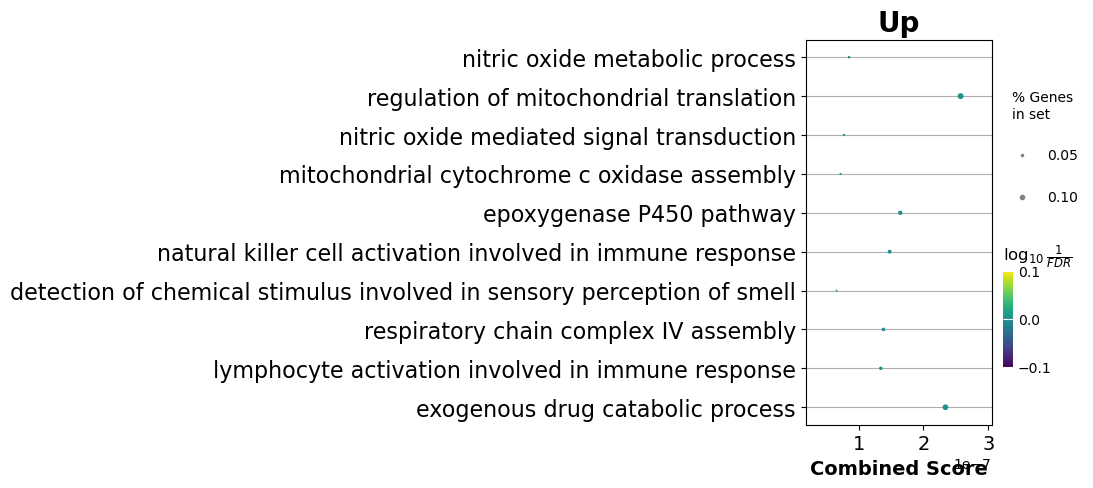

In [17]:
# Dotplot
# Dotplot with a different cutoff value
new_cutoff = 1  # Example: Change the cutoff value to 0.1
gp.dotplot(mast_5_enr_up.res2d, figsize=(3, 5), title="Up", cmap=plt.cm.viridis, cutoff=new_cutoff)
plt.show()
